**Instituto Brasileiro de Ensino, Desenvolvimento e Pesquisa**

Programa de Pós-Graduação em Administração Pública — Mestrado Profissional

**Disciplina:** Avaliação de Políticas Públicas com Dados  
**Atividade:** Resultados potenciais e critério de backdoor  
**Grupo:** Analécia Borato, Fabricio Santana, Giovane, Paulo Cézar

# Programa Mais Médicos e internações evitáveis em Goiás

[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fabriciosantana/mcdia/blob/main/09-appd/assignments/atividade_inferencia_causal_mais_medicos.ipynb)

Este notebook aplica o quadro de resultados potenciais e o critério de
backdoor para avaliar a entrada inicial do **Programa Mais Médicos (PMM)** nos
246 municípios de Goiás. O estimando é o **ATT** da presença de profissionais
ativos em 29 de novembro de 2013 sobre a média da taxa municipal de
**internações por condições sensíveis à atenção primária (ICSAP)** em
2014–2015. A análise compara 29 municípios inicialmente tratados a 217
municípios de comparação, utilizando covariáveis pré-tratamento e ponderação
por escore de propensão.

> **Conclusão em uma frase:** o ATT ajustado foi de −19,50 internações ICSAP
> por 10 mil habitantes, com intervalo bootstrap de 95% entre −83,11 e 34,16;
> a estimativa é compatível com redução, mas sua imprecisão, o desequilíbrio
> territorial residual e a mensuração incompleta dos confundidores não
> sustentam uma conclusão causal forte.

## Introdução

A inferência causal procura responder perguntas sobre o que aconteceria com
uma unidade — neste estudo, um município — sob diferentes intervenções. Essa
pergunta é distinta de uma descrição ou de uma associação estatística:
observar que municípios participantes do Programa Mais Médicos (PMM) têm taxas
de internação diferentes não demonstra, por si só, que o programa produziu a
diferença. Os municípios podem já diferir em vulnerabilidade, oferta de
serviços, capacidade administrativa e condições de saúde.

O quadro de **resultados potenciais** formaliza o problema. Para cada município
$i$, definem-se $Y_i(1)$, o resultado que seria observado com o tratamento, e
$Y_i(0)$, o resultado sem o tratamento. O efeito individual seria
$Y_i(1)-Y_i(0)$, mas apenas um desses resultados é observado para cada unidade.
O outro é o **contrafactual**. Essa impossibilidade de observar simultaneamente
os dois estados é o problema fundamental da inferência causal e exige construir
um grupo de comparação que represente, sob hipóteses explícitas, o que teria
ocorrido com os tratados na ausência do programa.

Como efeitos individuais não são diretamente observáveis, a análise define um
**estimando**, isto é, a quantidade causal que se deseja conhecer. O efeito
médio do tratamento na população é o ATE; o efeito médio entre os tratados é o
ATT; e o efeito médio entre os não tratados é o ATU. A escolha depende da
pergunta substantiva, e não apenas do método disponível. Neste notebook, o ATT
é o estimando relevante porque o interesse está nos municípios que receberam
profissionais na entrada inicial do PMM.

Em estudos observacionais, o tratamento não é distribuído aleatoriamente.
Surge, então, o problema da **seleção**: características que influenciam tanto
a participação no programa quanto o desfecho podem criar uma associação que
não corresponde ao efeito causal. Essas características são
**confundidores**. Comparar diretamente tratados e não tratados mistura o
efeito do programa com diferenças preexistentes, razão pela qual a linha de
base e outras covariáveis anteriores ao tratamento são importantes.

Um **grafo acíclico direcionado (DAG)** explicita as hipóteses sobre as relações
causais. No grafo, um caminho de **backdoor** liga tratamento e resultado por
uma causa anterior do tratamento. O critério de backdoor orienta a escolha de
um conjunto de ajuste que bloqueie esses caminhos sem bloquear o efeito que se
pretende estimar. Sob as hipóteses de consistência, ausência de interferência,
ignorabilidade condicional e positividade, o resultado dos controles
comparáveis pode representar o contrafactual dos tratados. A consistência
exige que o tratamento observado corresponda à intervenção definida; a
ausência de interferência pressupõe que o tratamento de um município não afete
o resultado de outro; a ignorabilidade condicional requer que, após o ajuste
pelas covariáveis, não permaneçam causas comuns não observadas do tratamento e
do resultado; e a positividade exige possibilidade de tratamento e não
tratamento para perfis comparáveis.

Nem toda variável associada ao resultado deve ser controlada. Um
**mediador** está no caminho pelo qual o tratamento produz o resultado;
condicioná-lo remove parte do efeito total. Um **colisor** é consequência de
duas variáveis; condicioná-lo pode abrir uma associação espúria. A escolha das
covariáveis deve, portanto, ser guiada pelo DAG e por sua posição temporal, e
não somente por significância estatística ou capacidade preditiva.

Mesmo com um conjunto de ajuste plausível, a identificação requer
**sobreposição** ou suporte comum: para perfis semelhantes de covariáveis, deve
haver municípios tratados e não tratados. O escore de propensão resume a
probabilidade de tratamento dadas as covariáveis e pode ser usado para
ponderação e diagnóstico de comparabilidade. Ele equilibra apenas variáveis
observadas; não corrige confundimento não medido nem torna causal uma análise
cujo DAG ou ordenamento temporal sejam inadequados. Intervalos de confiança,
por sua vez, representam incerteza amostral, não a incerteza sobre essas
hipóteses de identificação.

O notebook está organizado da seguinte forma: primeiro apresenta as fontes, o
processamento e a análise exploratória dos dados; depois define a política, a
pergunta causal, os resultados potenciais e o ATT; em seguida formula o DAG e
o conjunto de ajuste, constrói as variáveis empíricas e examina o suporte
comum; por fim estima o ATT, discute hipóteses e ameaças à validade, sintetiza
as conclusões e registra as referências utilizadas.

## Fontes de dados

A aplicação reúne três fontes administrativas oficiais, ligadas pelo código do
município do IBGE:

| Fonte | Informação utilizada | Forma de obtenção |
|---|---|---|
| Ministério da Saúde — série histórica do Programa de Provimento Federal/PMM | número de profissionais ativos por município em 29/11/2013 | arquivo CSV compactado disponibilizado no Portal de Dados Abertos do SUS |
| Secretaria de Estado da Saúde de Goiás — internações por condições sensíveis à atenção primária, derivadas do SIH/DATASUS | internações mensais por município de residência, região de saúde e classificação como numerador de ICSAP | arquivo CSV do Portal de Dados Abertos de Goiás |
| IBGE/SIDRA — tabela 6579 | estimativas da população municipal de 2013 a 2015 | consulta à API do SIDRA em formato JSON |

### Obtenção e armazenamento

Os dados foram obtidos diretamente dos canais oficiais. A série histórica do
PMM foi baixada em formato CSV compactado do
[Portal de Dados Abertos do SUS](https://dadosabertos.saude.gov.br/dataset/provimento-federal-programa-mais-medicos);
a base de internações foi baixada em CSV do
[Portal de Dados Abertos de Goiás](https://dadosabertos.go.gov.br/dataset/436edce3-5c43-4c79-8ba4-d9a48e8e1d1c/resource/b9c62bb7-dbd7-492e-a3be-822de01992fd);
e as estimativas populacionais foram consultadas em JSON pela API da tabela
6579 do [SIDRA/IBGE](https://apisidra.ibge.gov.br/).

No projeto, os arquivos devem ser armazenados com estes nomes exatos:

| Arquivo de origem | Local esperado |
|---|---|
| Série histórica do PMM | `09-appd/assignments/data/raw/ppf_mais_medicos_serie_historica.csv.zip` |
| Internações ICSAP de Goiás | `09-appd/assignments/data/raw/internacoes_icsap_go.csv` |
| População municipal | `09-appd/assignments/data/raw/populacao_go_2013_2015.json` |

Os arquivos brutos somam centenas de megabytes e não são versionados; a regra
em `data/raw/.gitignore` evita sua inclusão no repositório. A base pequena e
pronta para análise está armazenada em
`09-appd/assignments/data/processed/mais_medicos_icsap_go.csv`. Essa base
processada é versionada e contém uma linha para cada um dos 246 municípios, de
modo que o notebook pode ser executado sem rede e sem repetir os downloads.

### Como reconstruir a base analítica

Para reproduzir a base a partir das fontes originais, deve-se:

1. criar, se necessário, a pasta `09-appd/assignments/data/raw/`;
2. baixar os três arquivos oficiais e salvá-los nessa pasta com os nomes
   indicados na tabela anterior;
3. a partir da raiz do repositório, executar:

```bash
python 09-appd/assignments/preparar_dados_reais.py
```

O script abre o ZIP do PMM, lê o arquivo de internações em blocos para limitar
o uso de memória e interpreta a resposta JSON do SIDRA. Em seguida, padroniza
os códigos municipais em seis dígitos, restringe os registros a Goiás e aos
anos de 2013 a 2015, agrega as internações por município e período, integra as
estimativas populacionais e identifica o tratamento na fotografia de
29/11/2013. Por fim, calcula as taxas por 10 mil habitantes, a mudança pré–pós
e o logaritmo da população, ordena os municípios e grava novamente
`data/processed/mais_medicos_icsap_go.csv`.

Como controle de integridade, o script interrompe a execução se encontrar
municípios duplicados na fotografia inicial do PMM ou se a integração final
não resultar nos 246 municípios de Goiás. Assim, reconstruir a base não
significa apenas concatenar arquivos: o procedimento também verifica a unidade
de análise e a cobertura esperada.

As separações dos dados foram feitas para aproximar o desenho observacional da
ordem temporal da política:

- **Goiás:** foi escolhido porque a SES-GO oferece uma base oficial, municipal
  e previamente classificada segundo a lista brasileira de ICSAP. Essa escolha
  torna a construção transparente e reproduzível; uma base nacional exigiria
  baixar e classificar os microdados do SIH de todas as UFs. Em contrapartida,
  os resultados não devem ser generalizados automaticamente para o Brasil.
- **Tratamento inicial:** municípios com pelo menos um profissional ativo na
  fotografia de 29/11/2013 foram classificados como tratados; os demais
  formam o grupo de comparação. A fotografia fornece um critério comum e
  verificável de entrada inicial, embora municípios da comparação possam ter
  aderido posteriormente.
- **Período anterior:** janeiro a outubro de 2013 foi separado como linha de
  base por anteceder a fotografia do tratamento. Como são dez meses, as
  internações foram anualizadas por $12/10$ para ficarem na mesma escala das
  taxas anuais posteriores. Esse período não é totalmente pré-programa, pois o
  PMM foi lançado em julho de 2013; uma linha de base em 2012 seria mais limpa,
  mas a base goiana utilizada começa em 2013.
- **Período posterior:** 2014 e 2015 foram mantidos como dois anos completos
  após a entrada inicial. Calculou-se primeiro a taxa anual de cada ano e,
  depois, sua média, reduzindo a influência de flutuações de um único ano e
  dando tempo para mudanças na atenção básica afetarem as internações.

Em cada período, o numerador considera apenas registros classificados como
`Numerador` de ICSAP. As contagens foram divididas pela população municipal do
respectivo ano e multiplicadas por 10 mil. As demais internações clínicas
foram preservadas apenas para construir uma medida de utilização hospitalar
prévia usada no ajuste; elas não compõem o desfecho.

## Análise exploratória de dados

A análise exploratória tem dois objetivos. O primeiro é verificar se a base
analítica preserva a população municipal pretendida, não contém perdas ou
duplicações e representa corretamente a baixa frequência da entrada inicial no
PMM. O segundo é examinar diferenças preexistentes, heterogeneidade regional,
assimetria, valores extremos e comparabilidade entre os grupos. Essas
características orientam o DAG, a escolha das covariáveis e a interpretação dos
estimadores apresentados adiante.

As estatísticas desta seção são descritivas. Diferenças entre tratados e
controles, antes ou depois da política, não devem ser interpretadas
isoladamente como efeitos causais.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def localizar_base_exploratoria():
    candidatos = [
        Path("data/processed/mais_medicos_icsap_go.csv"),
        Path("09-appd/assignments/data/processed/mais_medicos_icsap_go.csv"),
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    raise FileNotFoundError("Base processada não encontrada.")

df_eda = pd.read_csv(
    localizar_base_exploratoria(), dtype={"cod_mun": str}
)

qualidade = pd.Series({
    "Linhas": len(df_eda),
    "Municípios distintos": df_eda["cod_mun"].nunique(),
    "Duplicações do código municipal": df_eda["cod_mun"].duplicated().sum(),
    "Valores ausentes": int(df_eda.isna().sum().sum()),
    "Regiões de saúde": df_eda["regiao_saude_residencia"].nunique(),
    "Municípios tratados": int(df_eda["tratado"].sum()),
    "Municípios de comparação": int((1 - df_eda["tratado"]).sum()),
}, name="Valor").to_frame()
qualidade

,Valor
Linhas,246
Municípios distintos,246
Duplicações do código municipal,0
Valores ausentes,0
Regiões de saúde,18
Municípios tratados,29
Municípios de comparação,217


A base tem os 246 municípios goianos, um registro por código municipal, sem
duplicações nem valores ausentes nas variáveis analíticas. Apenas 29 municípios
(11,8%) aparecem na fotografia inicial do PMM, contra 217 no grupo de
comparação. Essa forte diferença de tamanho é coerente com um tratamento
direcionado, favorece a escolha do ATT — centrado nos municípios efetivamente
atendidos — e exige atenção aos pesos: poucos controles comparáveis podem
receber influência elevada.

In [2]:
variaveis_eda = {
    "populacao_2014": "População em 2014",
    "taxa_icsap_pre": "ICSAP prévia",
    "taxa_clinicas_pre": "Internações clínicas prévias",
    "taxa_icsap_pos": "ICSAP em 2014–2015",
    "mudanca_taxa_icsap": "Mudança pré–pós",
}

linhas = []
for tratamento, grupo in df_eda.groupby("tratado"):
    for variavel, rotulo in variaveis_eda.items():
        q1, mediana, q3 = grupo[variavel].quantile([.25, .50, .75])
        linhas.append({
            "Grupo": "PMM inicial" if tratamento else "Comparação",
            "Variável": rotulo,
            "Média": grupo[variavel].mean(),
            "Desvio-padrão": grupo[variavel].std(),
            "Q1": q1,
            "Mediana": mediana,
            "Q3": q3,
        })

resumo_eda = pd.DataFrame(linhas)
resumo_eda.round(2)

,Grupo,Variável,Média,Desvio-padrão,Q1,Mediana,Q3
0,Comparação,População em 2014,15064.96,31952.18,3558.00,6189.00,13292.00
1,Comparação,ICSAP prévia,399.27,291.17,195.45,308.62,545.15
2,Comparação,Internações clínicas prévias,531.56,396.19,248.54,397.93,712.64
3,Comparação,ICSAP em 2014–2015,371.86,253.30,183.46,300.33,511.24
4,Comparação,Mudança pré–pós,-27.41,167.94,-72.12,-11.58,41.25
5,PMM inicial,População em 2014,112211.21,269965.10,9278.00,25805.00,104899.00
6,PMM inicial,ICSAP prévia,327.49,211.01,201.68,242.00,326.55
7,PMM inicial,Internações clínicas prévias,433.75,284.12,246.65,306.59,446.29
8,PMM inicial,ICSAP em 2014–2015,288.70,192.84,159.14,213.27,359.32
9,PMM inicial,Mudança pré–pós,-38.79,121.83,-63.65,-28.90,-1.98


Medianas e intervalos interquartis são apresentados ao lado das médias porque
população e taxas municipais são assimétricas. O município tratado mediano é
substancialmente maior que o controle mediano, evidência de seleção por porte
e razão para usar o logaritmo da população no modelo de tratamento. Os
tratados também começam com menor mediana de ICSAP. Logo, a diferença posterior
entre os grupos combina o nível inicial, o perfil dos municípios e uma eventual
resposta ao programa; comparar apenas as médias posteriores não recupera o
contrafactual.

A taxa de internações clínicas prévias inclui ICSAP e outras internações
clínicas. Ela funciona como proxy da utilização hospitalar e da oferta/risco
prévio, mas não substitui medidas diretas de cobertura da atenção primária,
vulnerabilidade ou capacidade administrativa.

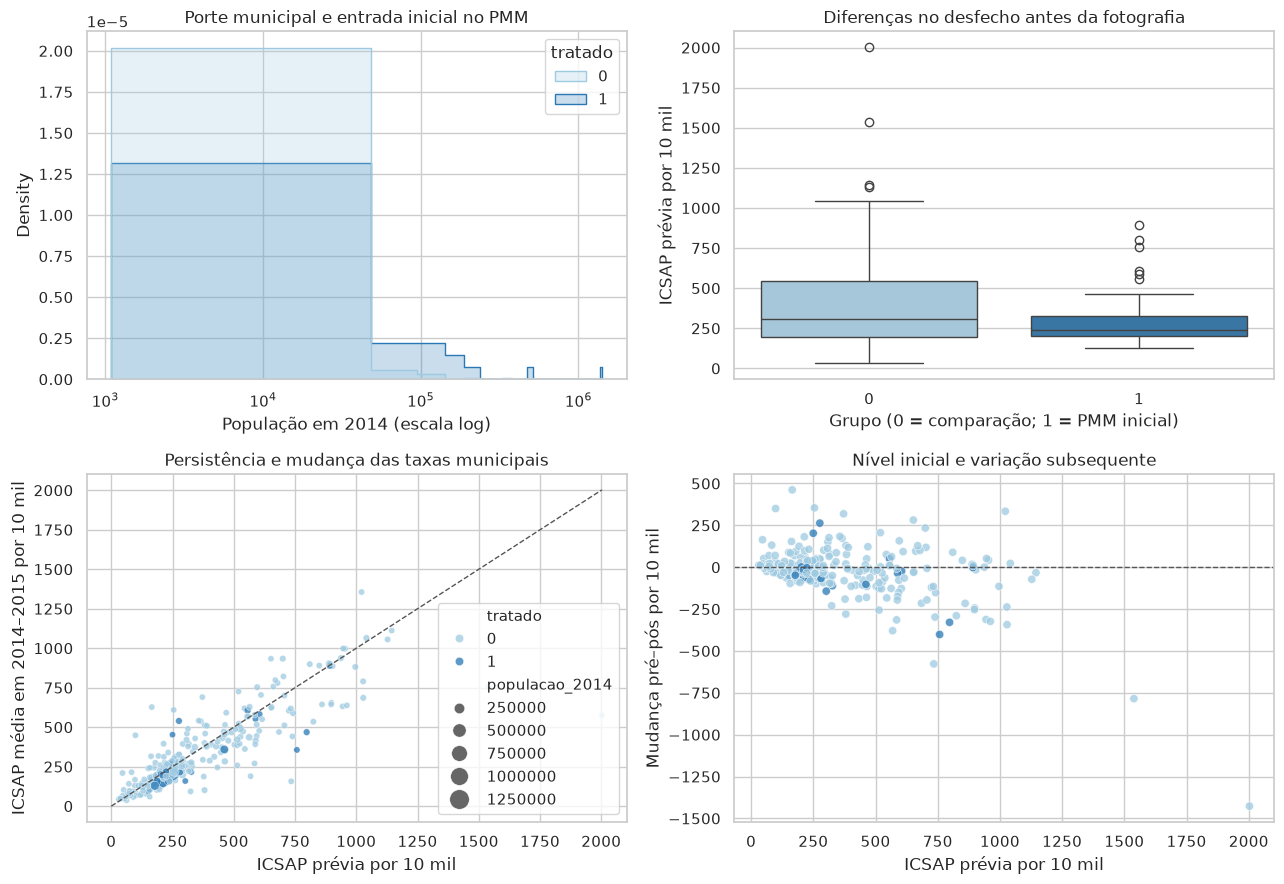

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(
    data=df_eda, x="populacao_2014", hue="tratado",
    bins=30, element="step", stat="density", common_norm=False,
    palette={0: "#9ecae1", 1: "#2878b5"}, ax=axes[0, 0]
)
axes[0, 0].set(
    xscale="log", xlabel="População em 2014 (escala log)",
    title="Porte municipal e entrada inicial no PMM"
)

sns.boxplot(
    data=df_eda, x="tratado", y="taxa_icsap_pre", hue="tratado",
    palette={0: "#9ecae1", 1: "#2878b5"}, legend=False, ax=axes[0, 1]
)
axes[0, 1].set(
    xlabel="Grupo (0 = comparação; 1 = PMM inicial)",
    ylabel="ICSAP prévia por 10 mil",
    title="Diferenças no desfecho antes da fotografia"
)

sns.scatterplot(
    data=df_eda, x="taxa_icsap_pre", y="taxa_icsap_pos",
    hue="tratado", size="populacao_2014", sizes=(20, 220), alpha=.75,
    palette={0: "#9ecae1", 1: "#2878b5"}, ax=axes[1, 0]
)
limite = max(df_eda["taxa_icsap_pre"].max(), df_eda["taxa_icsap_pos"].max())
axes[1, 0].plot([0, limite], [0, limite], "--", color="#555", linewidth=1)
axes[1, 0].set(
    xlabel="ICSAP prévia por 10 mil",
    ylabel="ICSAP média em 2014–2015 por 10 mil",
    title="Persistência e mudança das taxas municipais"
)

sns.scatterplot(
    data=df_eda, x="taxa_icsap_pre", y="mudanca_taxa_icsap",
    hue="tratado", alpha=.75,
    palette={0: "#9ecae1", 1: "#2878b5"}, ax=axes[1, 1], legend=False
)
axes[1, 1].axhline(0, color="#555", linestyle="--", linewidth=1)
axes[1, 1].set(
    xlabel="ICSAP prévia por 10 mil",
    ylabel="Mudança pré–pós por 10 mil",
    title="Nível inicial e variação subsequente"
)

plt.tight_layout()
plt.show()

Os gráficos revelam quatro aspectos importantes. Primeiro, os tratados se
concentram em municípios maiores, embora exista alguma sobreposição de porte.
Segundo, a distribuição da ICSAP prévia é ampla e contém valores extremos,
sobretudo entre controles pequenos; taxas baseadas em populações reduzidas são
mais voláteis. Terceiro, há persistência entre as taxas anterior e posterior,
o que confirma a relevância prognóstica do desfecho prévio. Quarto, municípios
com taxas iniciais muito elevadas tendem a apresentar quedas maiores. Esse
padrão pode combinar mudanças reais, limites naturais e regressão à média.
Assim, a diferença em mudanças é informativa, mas não elimina automaticamente
o confundimento e pode ser sensível a observações extremas.

In [4]:
por_regiao = (
    df_eda.groupby("regiao_saude_residencia", as_index=False)
    .agg(
        municipios=("cod_mun", "size"),
        tratados=("tratado", "sum"),
        taxa_icsap_pre=("taxa_icsap_pre", "median"),
        taxa_icsap_pos=("taxa_icsap_pos", "median"),
    )
)
por_regiao["proporcao_tratada"] = (
    100 * por_regiao["tratados"] / por_regiao["municipios"]
)
por_regiao = por_regiao.sort_values(
    ["proporcao_tratada", "municipios"], ascending=[False, False]
)
por_regiao.round(2)

,regiao_saude_residencia,municipios,tratados,taxa_icsap_pre,taxa_icsap_pos,proporcao_tratada
3,ENTORNO SUL,7,6,208.78,149.99,85.71
2,ENTORNO NORTE,8,5,205.63,158.38,62.50
5,NORDESTE I,5,3,242.00,213.27,60.00
10,PIRENEUS,10,3,175.82,149.99,30.00
0,CENTRAL,26,6,388.70,306.12,23.08
6,NORDESTE II,11,2,434.08,283.38,18.18
1,CENTRO SUL,25,4,380.64,395.36,16.00
12,SAO PATRICIO I,20,0,341.18,338.48,0.00
4,ESTRADA DE FERRO,18,0,313.24,348.14,0.00
15,SUDOESTE I,18,0,244.68,262.10,0.00


A entrada inicial também é espacialmente concentrada. Há regiões com alta
proporção de municípios tratados e outras sem nenhum tratado. Região de saúde
pode representar redes assistenciais, acesso hospitalar, distância e critérios
territoriais de priorização; por isso, ela entra como covariável categórica no
escore de propensão. Contudo, regiões sem variação interna de tratamento não
oferecem comparações tratadas–controle dentro da própria região. O ajuste passa
a depender de comparações entre regiões e de extrapolação do modelo, uma
limitação de positividade que deve moderar a interpretação causal.

In [5]:
correlacoes = (
    df_eda[
        [
            "taxa_icsap_pre", "taxa_clinicas_pre", "log_populacao",
            "taxa_icsap_pos", "mudanca_taxa_icsap", "tratado",
        ]
    ]
    .corr()
    .round(3)
)

extremos = pd.concat(
    [
        df_eda.nsmallest(5, "mudanca_taxa_icsap"),
        df_eda.nlargest(5, "mudanca_taxa_icsap"),
    ]
)[
    [
        "municipio_residencia", "tratado", "populacao_2014",
        "taxa_icsap_pre", "taxa_icsap_pos", "mudanca_taxa_icsap",
    ]
].sort_values("mudanca_taxa_icsap")

print("Matriz de correlações")
display(correlacoes)
print("Cinco maiores quedas e cinco maiores aumentos")
display(extremos.round(2))

Matriz de correlações


,taxa_icsap_pre,taxa_clinicas_pre,log_populacao,taxa_icsap_pos,mudanca_taxa_icsap,tratado
taxa_icsap_pre,1.000,0.991,0.002,0.820,-0.491,-0.082
taxa_clinicas_pre,0.991,1.000,0.003,0.834,-0.455,-0.082
log_populacao,0.002,0.003,1.000,-0.016,-0.027,0.393
taxa_icsap_pos,0.820,0.834,-0.016,1.000,0.096,-0.108
mudanca_taxa_icsap,-0.491,-0.455,-0.027,0.096,1.000,-0.023
tratado,-0.082,-0.082,0.393,-0.108,-0.023,1.000


Cinco maiores quedas e cinco maiores aumentos


,municipio_residencia,tratado,populacao_2014,taxa_icsap_pre,taxa_icsap_pos,mudanca_taxa_icsap
138,MARZAGAO,0,2184,2002.77,576.08,-1426.69
11,ALVORADA DO NORTE,0,8499,1538.35,753.66,-784.70
228,TAQUARAL DE GOIAS,0,3627,734.29,157.17,-577.12
23,ARAGOIANIA,1,9278,757.58,356.03,-401.54
8,ALOANDIA,0,2084,568.69,189.73,-378.96
67,CORREGO DO OURO,0,2590,371.56,690.53,318.97
153,MUNDO NOVO,0,6046,1021.36,1355.62,334.26
121,ITARUMA,0,6777,98.51,448.91,350.40
105,HIDROLINA,0,3966,254.62,609.10,354.48
151,MOSSAMEDES,0,4878,165.18,627.23,462.05


A correlação elevada entre ICSAP prévia e internações clínicas prévias indica
que as duas covariáveis carregam informação semelhante. Elas foram mantidas
porque têm papéis substantivos diferentes — nível anterior do próprio desfecho
e utilização hospitalar geral —, mas essa proximidade pode tornar coeficientes
individuais instáveis; o interesse do modelo de propensão é a probabilidade
prevista, não a interpretação isolada desses coeficientes.

Os municípios com as maiores variações merecem inspeção porque podem dominar
médias e resultados de bootstrap. Não há evidência, apenas pela magnitude, de
erro: parte da dispersão é esperada em taxas municipais, sobretudo onde a
população é pequena. Por isso, observações não são excluídas
automaticamente. A base preserva a população-alvo completa, e a incerteza é
avaliada por reamostragem. Como análise de sensibilidade adicional, seria
razoável comparar estimativas robustas, truncamento de pesos e modelos para
contagens com exposição populacional.

Em síntese, a exploração mostra seleção clara por porte e território,
diferenças preexistentes no desfecho, forte persistência das ICSAP e
heterogeneidade relevante. Esses achados justificam ajustar por desfecho e
utilização hospitalar prévios, log da população e região; também mostram por
que esse conjunto é incompleto. Ele não mede diretamente vulnerabilidade,
oferta anterior de médicos, cobertura da APS ou capacidade administrativa.
Portanto, o ajuste melhora a comparabilidade observada, mas não garante a
identificação causal.

## Política, pergunta e desenho

O PMM foi instituído em 2013 para ampliar o provimento médico em áreas com
dificuldade de atração e fixação de profissionais. Uma cadeia causal plausível
é:

$$\text{PMM}\rightarrow\text{acesso à atenção básica}
\rightarrow\text{prevenção e manejo precoce}\rightarrow\text{menos ICSAP}.$$

**Pergunta causal:** qual foi o efeito de participar da primeira fase do PMM
sobre a taxa de ICSAP, em 2014–2015, nos municípios goianos que receberam
profissionais até 29 de novembro de 2013?

| Elemento | Definição operacional |
|---|---|
| Unidade | município de Goiás |
| População | 246 municípios existentes no período |
| Tratamento $D_i$ | 1 se havia ao menos um profissional ativo do PMM em 29/11/2013; 0 caso contrário |
| Linha de base | janeiro–outubro de 2013, antes da fotografia do tratamento |
| Resultado $Y_i$ | média da taxa anual de ICSAP por 10 mil habitantes em 2014 e 2015 |
| Estimando | ATT da entrada inicial no programa |

A definição é semelhante a uma análise por atribuição inicial: municípios do
grupo de comparação podem ter ingressado depois. Isso tende a reduzir o
contraste entre os grupos e deve ser lembrado na interpretação.

## Resultados potenciais e estimando

Para cada município $i$:

$$Y_i(1)=\text{taxa de ICSAP em 2014–2015 sob entrada inicial no PMM},$$

$$Y_i(0)=\text{taxa de ICSAP em 2014–2015 sem entrada inicial no PMM}.$$

Observamos apenas:

$$Y_i=D_iY_i(1)+(1-D_i)Y_i(0).$$

O estimando é:

$$ATT=E[Y(1)-Y(0)\mid D=1].$$

Ele responde à decisão substantiva de interesse: **quanto a taxa de ICSAP dos
municípios inicialmente atendidos teria mudado, em média, se esses mesmos
municípios não tivessem entrado na fase inicial?** O ATT é preferível ao ATE
porque a política selecionou localidades específicas e não há razão para supor
efeitos homogêneos em todos os municípios.

## DAG e critério de backdoor

O DAG abaixo representa hipóteses causais. Variáveis com sufixo “pré” são
anteriores ao tratamento.

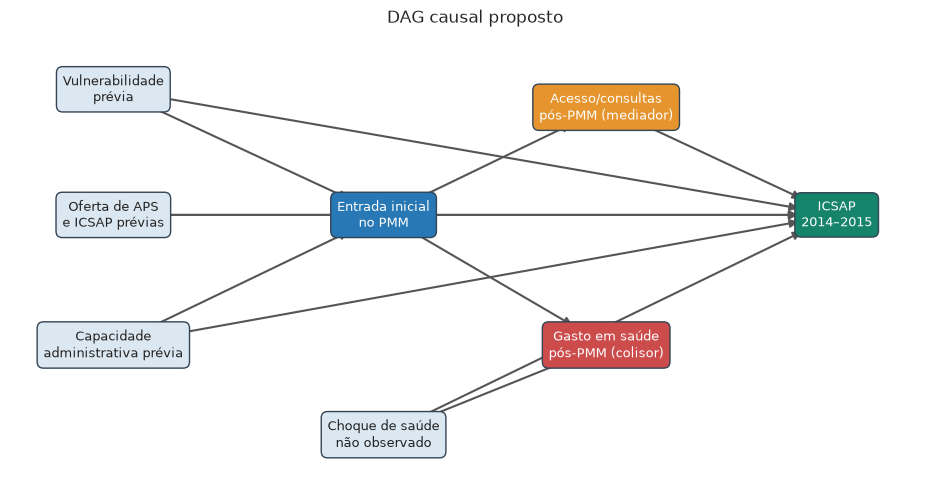

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_SEED = 20260723

def desenhar_dag():
    pos = {
        "V": (0.04, .82), "B": (.04, .54), "G": (.04, .25),
        "D": (.38, .54), "M": (.66, .78), "K": (.66, .25),
        "U": (.38, .05), "Y": (.95, .54)
    }
    labels = {
        "V": "Vulnerabilidade\nprévia",
        "B": "Oferta de APS\ne ICSAP prévias",
        "G": "Capacidade\nadministrativa prévia",
        "D": "Entrada inicial\nno PMM",
        "M": "Acesso/consultas\npós-PMM (mediador)",
        "K": "Gasto em saúde\npós-PMM (colisor)",
        "U": "Choque de saúde\nnão observado",
        "Y": "ICSAP\n2014–2015",
    }
    edges = [
        ("V","D"), ("V","Y"), ("B","D"), ("B","Y"), ("G","D"), ("G","Y"),
        ("D","M"), ("M","Y"), ("D","Y"), ("D","K"), ("U","K"), ("U","Y")
    ]
    colors = {"D":"#2878b5", "Y":"#16836b", "M":"#e6952e", "K":"#cc4c4c"}
    fig, ax = plt.subplots(figsize=(12, 6))
    for a, b in edges:
        ax.annotate("", xy=pos[b], xytext=pos[a],
                    arrowprops={"arrowstyle":"-|>", "lw":1.5, "color":"#555",
                                "shrinkA":28, "shrinkB":28})
    for node, (x, y) in pos.items():
        ax.text(x, y, labels[node], ha="center", va="center", fontsize=9.5,
                color="white" if node in colors else "#222",
                bbox={"boxstyle":"round,pad=.48", "fc":colors.get(node,"#dce8f1"),
                      "ec":"#345"})
    ax.set(xlim=(-.09, 1.08), ylim=(-.08, .95), title="DAG causal proposto")
    ax.axis("off")
    plt.show()

desenhar_dag()

Os caminhos de backdoor postulados são:

$$D\leftarrow V\rightarrow Y,\qquad
D\leftarrow B\rightarrow Y,\qquad
D\leftarrow G\rightarrow Y.$$

Logo, $Z=\{V,B,G\}$ é um conjunto de ajuste suficiente **no DAG teórico**:
não contém descendentes de $D$ e bloqueia todos os caminhos que entram em $D$
por uma seta. Sob

$$(Y(1),Y(0))\perp D\mid Z,$$

o ATT pode ser identificado por:

$$ATT=E\{E[Y\mid D=1,Z]-E[Y\mid D=0,Z]\mid D=1\}.$$

### O que controlar — e o que não controlar

| Variável | Papel | Controlar para efeito total? | Justificativa |
|---|---|---:|---|
| Vulnerabilidade socioeconômica prévia ($V$) | confundidor | sim | afeta priorização e risco de internação |
| Oferta de APS/ICSAP prévias ($B$) | confundidor | sim | afeta seleção e resultado |
| Capacidade administrativa prévia ($G$) | confundidor | sim | afeta adesão, execução e saúde |
| Acesso/consultas depois do PMM ($M$) | mediador | não | bloquearia parte do efeito total |
| Gasto em saúde posterior ($K$) | colisor plausível | não | condicioná-lo abre $D\to K\leftarrow U\to Y$ |
| Choque de saúde ($U$) | causa do resultado | não no DAG | não causa $D$; associa-se a $D$ se $K$ for condicionado |

O banco empírico mede bem a ICSAP prévia e o porte populacional, mas não contém
medidas completas de $V$, $B$ e $G$. A utilização hospitalar prévia e a região
de saúde são proxies imperfeitas. Por isso, a ignorabilidade condicional é uma
hipótese substantiva forte, não um resultado demonstrado pelos dados.

## Dados reais e construção das variáveis

As fontes são:

1. **Ministério da Saúde:** série histórica municipal do Programa de
   Provimento Federal/PMM;
2. **SES-GO, com dados do SIH/DATASUS:** internações classificadas conforme a
   lista brasileira de ICSAP;
3. **IBGE/SIDRA (tabela 6579):** estimativas populacionais municipais.

O arquivo analítico tem uma linha por município e acompanha o notebook, de
modo que sua execução não depende da internet. O script
`preparar_dados_reais.py` documenta a transformação dos arquivos brutos.

A linha de base usa janeiro–outubro de 2013 e é anualizada por $12/10$. O
resultado posterior é a média das taxas anuais de 2014 e 2015. A taxa é:

$$\text{taxa de ICSAP}_{it}=
\frac{\text{internações ICSAP}_{it}}{\text{população}_{it}}\times10.000.$$

In [7]:
def localizar_base():
    candidatos = [
        Path("data/processed/mais_medicos_icsap_go.csv"),
        Path("09-appd/assignments/data/processed/mais_medicos_icsap_go.csv"),
    ]
    for caminho in candidatos:
        if caminho.exists():
            return caminho
    raise FileNotFoundError("Base processada não encontrada.")

df = pd.read_csv(localizar_base(), dtype={"cod_mun": str})
print(f"Municípios: {len(df)}")
print(df["tratado"].value_counts().rename(index={0:"Comparação", 1:"PMM inicial"}))
df.head()

Municípios: 246
tratado
Comparação     217
PMM inicial     29
Name: count, dtype: int64


,cod_mun,municipio_residencia,regiao_saude_residencia,tratado,medicos_pmm_inicial,populacao_2014,log_populacao,taxa_icsap_pre,taxa_clinicas_pre,taxa_icsap_pos,mudanca_taxa_icsap
0,520005,ABADIA DE GOIAS,CENTRAL,0,0.0,7733,8.953252,275.934981,350.469142,326.226472,50.291491
1,520010,ABADIANIA,PIRENEUS,1,3.0,17701,9.781376,128.131132,155.835161,123.787997,-4.343135
2,520013,ACREUNA,SUDOESTE I,0,0.0,21549,9.978085,420.106712,592.530188,312.729791,-107.376921
3,520015,ADELANDIA,OESTE II,0,0.0,2554,7.845416,150.588235,211.764706,90.013472,-60.574763
4,520017,AGUA FRIA DE GOIAS,ENTORNO NORTE,0,0.0,5451,8.603554,62.279889,73.401297,37.421228,-24.858661


## Diagnóstico do ajuste e suporte comum

In [8]:
variaveis = ["taxa_icsap_pre", "taxa_clinicas_pre", "populacao_2014"]
resumo = df.groupby("tratado")[variaveis].mean().T
resumo.columns = ["Comparação", "PMM inicial"]
resumo["Diferença"] = resumo["PMM inicial"] - resumo["Comparação"]
resumo.round(2)

,Comparação,PMM inicial,Diferença
taxa_icsap_pre,399.27,327.49,-71.78
taxa_clinicas_pre,531.56,433.75,-97.81
populacao_2014,15064.96,112211.21,97146.24


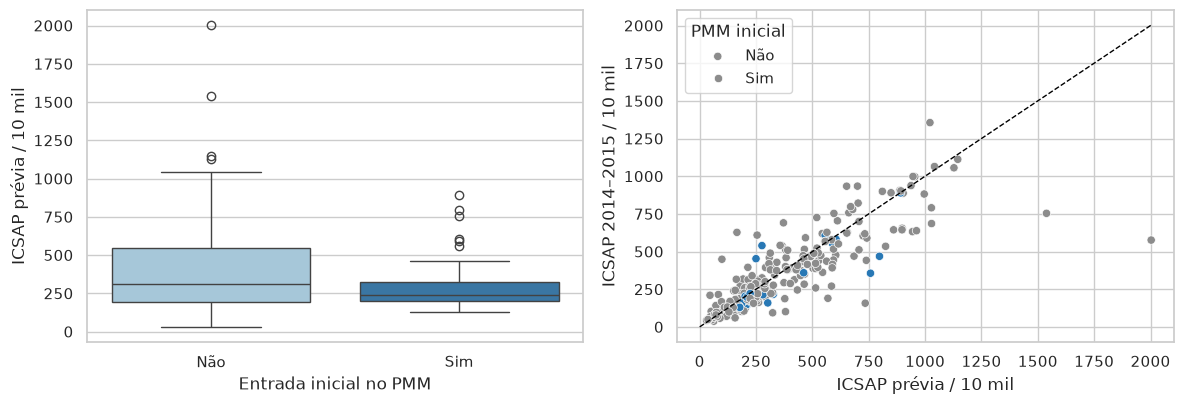

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.boxplot(data=df, x="tratado", y="taxa_icsap_pre", ax=axes[0],
            palette=["#9ecae1", "#2878b5"], hue="tratado", legend=False)
axes[0].set(xlabel="Entrada inicial no PMM", ylabel="ICSAP prévia / 10 mil",
            xticks=[0,1], xticklabels=["Não", "Sim"])
sns.scatterplot(data=df, x="taxa_icsap_pre", y="taxa_icsap_pos",
                hue="tratado", palette={0:"#8c8c8c",1:"#2878b5"}, ax=axes[1])
lim = [0, max(df["taxa_icsap_pre"].max(), df["taxa_icsap_pos"].max())]
axes[1].plot(lim, lim, "--", color="black", lw=1)
axes[1].set(xlabel="ICSAP prévia / 10 mil", ylabel="ICSAP 2014–2015 / 10 mil")
axes[1].legend(title="PMM inicial", labels=["Não", "Sim"])
plt.tight_layout()
plt.show()

Diferenças na linha de base confirmam que o tratamento não foi aleatório. O
balanceamento descritivo não prova nem refuta identificação; ele apenas mostra
que a comparação bruta não deve ser interpretada automaticamente como causal.

Estimamos a probabilidade de entrada inicial com variáveis **pré-tratamento**:
taxa prévia de ICSAP, taxa prévia de internações clínicas, log da população e
região de saúde. O escore serve como diagnóstico de sobreposição e para
ponderação do grupo de comparação.

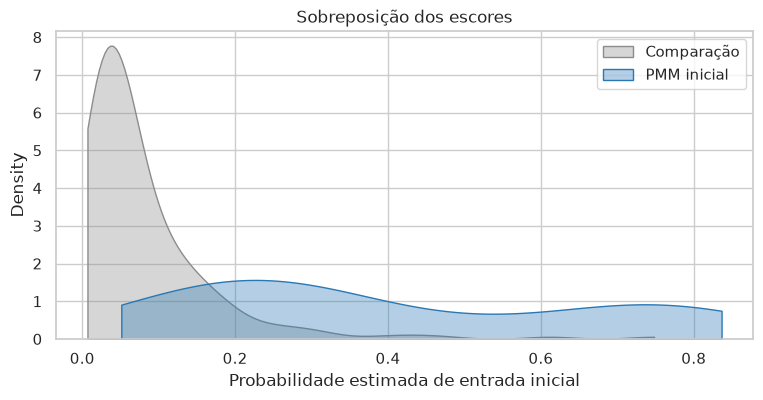

,min,median,max
tratado,,,
0,0.007,0.046,0.748
1,0.051,0.303,0.836


In [10]:
numericas = ["taxa_icsap_pre", "taxa_clinicas_pre", "log_populacao"]
categoricas = ["regiao_saude_residencia"]
X = df[numericas + categoricas]

preprocessador = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categoricas),
])
modelo_ps = make_pipeline(
    preprocessador,
    LogisticRegression(C=1.0, max_iter=5_000, random_state=RANDOM_SEED),
)
modelo_ps.fit(X, df["tratado"])
df["escore"] = modelo_ps.predict_proba(X)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
for d, cor, rotulo in [(0,"#8c8c8c","Comparação"), (1,"#2878b5","PMM inicial")]:
    sns.kdeplot(df.loc[df.tratado.eq(d), "escore"], fill=True, alpha=.35,
                color=cor, label=rotulo, ax=ax, cut=0)
ax.set(xlabel="Probabilidade estimada de entrada inicial", title="Sobreposição dos escores")
ax.legend()
plt.show()

df.groupby("tratado")["escore"].agg(["min","median","max"]).round(3)

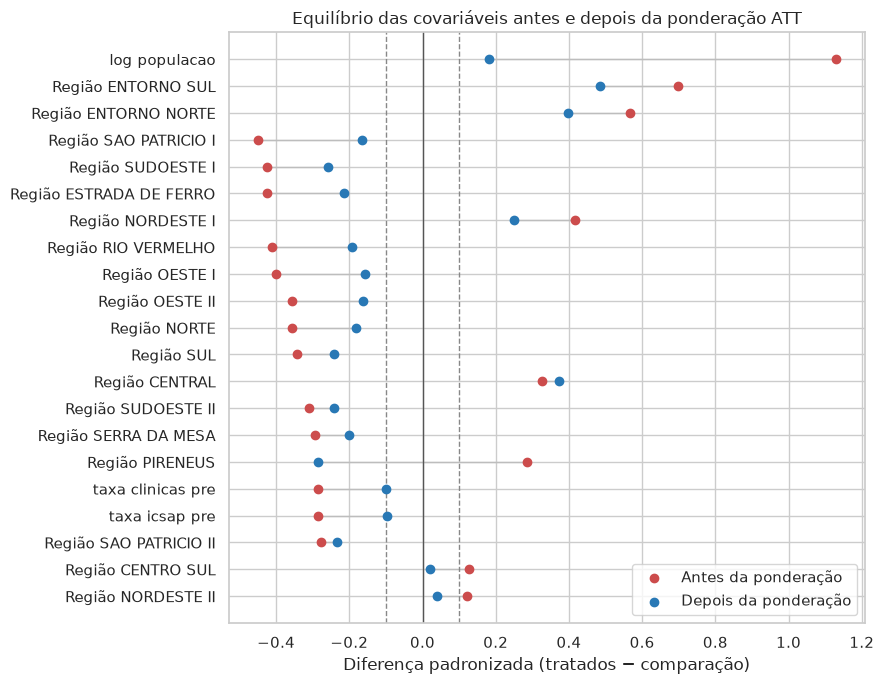

,Covariável,Antes,Depois,|Depois|
19,Região ENTORNO SUL,0.697,0.484,0.484
18,Região ENTORNO NORTE,0.567,0.397,0.397
8,Região CENTRAL,0.326,0.373,0.373
5,Região PIRENEUS,0.286,-0.285,0.285
16,Região SUDOESTE I,-0.425,-0.259,0.259
14,Região NORDESTE I,0.418,0.250,0.250
7,Região SUDOESTE II,-0.311,-0.242,0.242
9,Região SUL,-0.342,-0.241,0.241
2,Região SAO PATRICIO II,-0.277,-0.233,0.233
15,Região ESTRADA DE FERRO,-0.425,-0.215,0.215


In [11]:
# Diferenças padronizadas para todas as covariáveis usadas no escore.
# Para o ATT, tratados recebem peso 1 e controles recebem e(Z)/(1-e(Z)).
X_balanceamento = pd.concat(
    [
        df[numericas],
        pd.get_dummies(
            df["regiao_saude_residencia"],
            prefix="Região", dtype=float,
        ),
    ],
    axis=1,
).astype(float)

tratado = df["tratado"].eq(1).to_numpy()
pesos_att = np.where(tratado, 1.0, df["escore"] / (1 - df["escore"]))

def media_ponderada(x, w):
    return np.average(x, weights=w)

def variancia_ponderada(x, w):
    media = media_ponderada(x, w)
    return np.average((x - media) ** 2, weights=w)

def diferenca_padronizada(x, pesos_controle):
    xt, xc = x[tratado], x[~tratado]
    # O mesmo denominador pré-ajuste torna o antes/depois comparável.
    desvio_agrupado = np.sqrt((np.var(xt) + np.var(xc)) / 2)
    if desvio_agrupado == 0:
        return 0.0, 0.0
    antes = (np.mean(xt) - np.mean(xc)) / desvio_agrupado
    depois = (
        np.mean(xt)
        - media_ponderada(xc, pesos_controle[~tratado])
    ) / desvio_agrupado
    return antes, depois

linhas_balanceamento = []
for coluna in X_balanceamento:
    antes, depois = diferenca_padronizada(
        X_balanceamento[coluna].to_numpy(), pesos_att
    )
    linhas_balanceamento.append(
        {
            "Covariável": coluna.replace("_", " "),
            "Antes": antes,
            "Depois": depois,
            "|Antes|": abs(antes),
            "|Depois|": abs(depois),
        }
    )

balanceamento = (
    pd.DataFrame(linhas_balanceamento)
    .sort_values("|Antes|", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(balanceamento))
ax.scatter(
    balanceamento["Antes"], y, color="#cc4c4c",
    label="Antes da ponderação", zorder=3,
)
ax.scatter(
    balanceamento["Depois"], y, color="#2878b5",
    label="Depois da ponderação", zorder=3,
)
for yi, antes, depois in zip(
    y, balanceamento["Antes"], balanceamento["Depois"]
):
    ax.plot([antes, depois], [yi, yi], color="#bdbdbd", linewidth=1)
ax.axvline(0, color="#555", linewidth=1)
ax.axvline(-.10, color="#888", linestyle="--", linewidth=1)
ax.axvline(.10, color="#888", linestyle="--", linewidth=1)
ax.set(
    yticks=y,
    yticklabels=balanceamento["Covariável"],
    xlabel="Diferença padronizada (tratados − comparação)",
    title="Equilíbrio das covariáveis antes e depois da ponderação ATT",
)
ax.legend()
plt.tight_layout()
plt.show()

display(
    balanceamento.sort_values("|Depois|", ascending=False)
    [["Covariável", "Antes", "Depois", "|Depois|"]]
    .round(3)
)

O gráfico de diferenças padronizadas compara a distância entre tratados e
controles em uma escala comum. Valores próximos de zero indicam maior
equilíbrio; as linhas verticais em $\pm0{,}10$ são referências descritivas, não
um teste ou uma garantia de identificação. A ponderação deve ser julgada pela
redução conjunta dos desequilíbrios e pela existência de suporte comum.

Neste caso, a ponderação reduz substancialmente o desequilíbrio do log da
população e leva as duas taxas prévias para próximo da referência de 0,10.
Entretanto, permanecem diferenças relevantes em várias regiões de saúde,
especialmente Entorno Sul, Entorno Norte e Central. Portanto, o modelo melhora
a comparabilidade nas covariáveis contínuas, mas não produz equilíbrio
territorial satisfatório. Esse resultado é coerente com regiões que não têm
variação interna de tratamento e constitui uma limitação concreta da estimativa
ponderada.

Mesmo quando o equilíbrio observado melhora, isso não demonstra que o
backdoor foi completamente bloqueado: o diagnóstico alcança apenas as
covariáveis incluídas e suas categorias observadas. Confundidores ausentes,
erros de mensuração e especificação inadequada do escore continuam possíveis.
Por essa razão, os resultados seguintes são descritos como estimativas
observacionais ajustadas sob as hipóteses declaradas.

## Estimação do ATT

São mostradas três quantidades:

1. **diferença bruta** entre as taxas posteriores;
2. **diferença em mudanças**, que desconta a taxa prévia;
3. **ATT ponderado**, no qual municípios de comparação recebem peso
   $e(Z)/(1-e(Z))$ e os pesos são normalizados para representar a distribuição
   de $Z$ entre os tratados.

O terceiro estimador implementa o ajuste proposto com as covariáveis
disponíveis, mas só tem interpretação causal se o conjunto observado bloquear
todo confundimento relevante. Intervalos percentis são obtidos por bootstrap
municipal e representam incerteza amostral, não incerteza sobre o DAG.

In [12]:
def estimativas(data, seed=RANDOM_SEED):
    Xb = data[numericas + categoricas]
    ps = make_pipeline(
        preprocessador,
        LogisticRegression(C=1.0, max_iter=5_000, random_state=seed),
    )
    ps.fit(Xb, data["tratado"])
    e = np.clip(ps.predict_proba(Xb)[:, 1], .01, .99)
    tratados = data["tratado"].eq(1).to_numpy()
    y = data["taxa_icsap_pos"].to_numpy()
    mudanca = data["mudanca_taxa_icsap"].to_numpy()
    pesos_controle = e[~tratados] / (1 - e[~tratados])
    return np.array([
        y[tratados].mean() - y[~tratados].mean(),
        mudanca[tratados].mean() - mudanca[~tratados].mean(),
        y[tratados].mean() - np.average(y[~tratados], weights=pesos_controle),
    ])

nomes = ["Diferença bruta", "Diferença em mudanças", "ATT ponderado"]
ponto = estimativas(df)

rng = np.random.default_rng(RANDOM_SEED)
boots = []
for b in range(500):
    # Reamostragem estratificada preserva tratados e controles em cada réplica.
    partes = []
    for d in [0, 1]:
        grupo = df.loc[df.tratado.eq(d)]
        idx = rng.integers(0, len(grupo), len(grupo))
        partes.append(grupo.iloc[idx])
    amostra = pd.concat(partes, ignore_index=True)
    try:
        boots.append(estimativas(amostra, seed=RANDOM_SEED + b + 1))
    except ValueError:
        continue
boots = np.asarray(boots)

resultado = pd.DataFrame({
    "Estimativa": ponto,
    "IC 2,5%": np.quantile(boots, .025, axis=0),
    "IC 97,5%": np.quantile(boots, .975, axis=0),
}, index=nomes)
resultado.round(2)

,Estimativa,"IC 2,5%","IC 97,5%"
Diferença bruta,-83.16,-156.36,-2.97
Diferença em mudanças,-11.38,-60.86,33.03
ATT ponderado,-19.50,-83.11,34.16


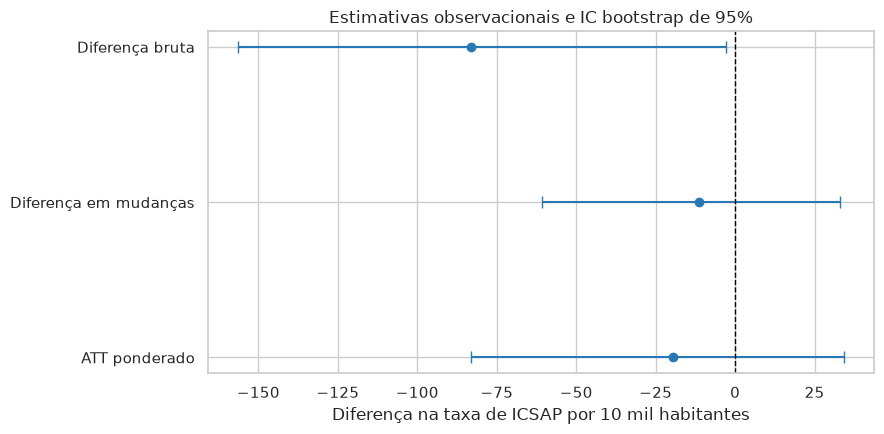

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ypos = np.arange(len(resultado))
ax.errorbar(resultado["Estimativa"], ypos,
            xerr=[resultado["Estimativa"]-resultado["IC 2,5%"],
                  resultado["IC 97,5%"]-resultado["Estimativa"]],
            fmt="o", color="#2878b5", capsize=4)
ax.axvline(0, color="black", ls="--", lw=1)
ax.set(yticks=ypos, yticklabels=resultado.index,
       xlabel="Diferença na taxa de ICSAP por 10 mil habitantes",
       title="Estimativas observacionais e IC bootstrap de 95%")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Leitura correta dos resultados

- A diferença bruta mistura o possível efeito do programa com seleção dos
  municípios.
- A diferença em mudanças desconta níveis prévios, mas exigiria tendências
  paralelas para uma interpretação causal longitudinal.
- O ATT ponderado compara os tratados a controles reponderados segundo as
  covariáveis observadas. Ele é a principal **ilustração do backdoor**, não uma
  validação de que o backdoor foi inteiramente bloqueado.
- Um intervalo que inclua zero indica imprecisão compatível tanto com redução
  quanto com aumento da taxa. Mesmo que não inclua zero, confundimento residual
  ainda poderia explicar parte da associação.

Em particular, não devemos escrever “o PMM causou uma redução de X” apenas com
esta análise. A formulação defensável é: “a estimativa ajustada foi X, sob as
hipóteses declaradas e com as limitações de mensuração descritas”.

## Hipóteses e ameaças à validade

- **Consistência:** “entrada inicial” reúne doses e perfis profissionais
  diferentes. O tratamento precisa ser interpretado como a política tal como
  implementada, não como uma dose homogênea.
- **Positividade:** deve haver municípios tratados e não tratados comparáveis
  em cada perfil de covariáveis. A distribuição dos escores deve ser examinada;
  extrapolação para tratados sem controles semelhantes fragiliza o ATT.
- **Ausência de confundimento não observado:** é a hipótese mais fraca da
  aplicação. Vulnerabilidade, oferta prévia de médicos e capacidade
  administrativa não estão integralmente medidas.
- **Não interferência:** pacientes e médicos podem atravessar fronteiras
  municipais, violando SUTVA.
- **Ordenação temporal:** somente variáveis anteriores a 29/11/2013 entram no
  ajuste. Consultas, cobertura e gastos posteriores foram deliberadamente
  excluídos.
- **Adoção posterior:** municípios classificados como comparação podem receber
  o PMM em 2014–2015, reduzindo o contraste.
- **Mensuração:** o SIH cobre internações financiadas pelo SUS; erros de
  residência, codificação diagnóstica e população afetam as taxas.
- **Poucos tratados:** há apenas 29 municípios na coorte inicial em Goiás, o
  que limita precisão e flexibilidade do modelo.
- **Validade externa:** o ATT goiano não se transporta automaticamente para o
  Brasil ou para municípios não tratados.

Uma avaliação de impacto mais forte acrescentaria dados pré-tratamento de
CNES/ESF, vulnerabilidade do Censo/Atlas Brasil e capacidade fiscal e
administrativa; verificaria suporte comum; examinaria a data exata de entrada;
e exploraria um painel com adoção escalonada e tendências prévias.

## Conclusão

Este trabalho aplicou o quadro de resultados potenciais e o critério de
backdoor à avaliação da entrada inicial do Programa Mais Médicos nos municípios
de Goiás. O estimando escolhido foi o ATT, entendido como o efeito médio da
entrada inicial no programa sobre a taxa de internações por condições sensíveis
à atenção primária dos municípios que receberam profissionais até 29 de
novembro de 2013.

O DAG mostrou que a comparação direta entre municípios tratados e não tratados
não identifica automaticamente esse efeito. Vulnerabilidade socioeconômica,
oferta prévia de atenção básica e capacidade administrativa municipal são
confundidores plausíveis e devem ser controlados. Em contrapartida, consultas
posteriores ao PMM não devem ser controladas na estimação do efeito total, pois
constituem um possível mediador. O gasto municipal em saúde posterior também
não deve ser condicionado quando funciona como colisor entre a entrada no
programa e choques de saúde não observados.

Na aplicação empírica, a diferença bruta foi de −83,16 internações ICSAP por 10
mil habitantes, enquanto a diferença em mudanças foi de −11,38. Após a
ponderação pelo escore de propensão, o ATT estimado foi de −19,50 internações
por 10 mil habitantes, com intervalo bootstrap de 95% entre −83,11 e 34,16. A
estimativa pontual é compatível com uma redução das internações, mas o intervalo
é amplo e inclui zero. Portanto, os dados também são compatíveis com ausência
de efeito ou com um pequeno aumento.

Esses resultados não permitem afirmar que o PMM causou uma redução das ICSAP.
O ajuste utiliza taxa prévia de ICSAP, utilização hospitalar anterior, porte
populacional e região de saúde, mas não mede integralmente vulnerabilidade,
oferta anterior de médicos, cobertura da atenção primária ou capacidade
administrativa. Além disso, a linha de base de 2013 não é completamente
anterior ao lançamento do programa, municípios do grupo de comparação podem
ter ingressado posteriormente e existe concentração regional do tratamento. A
hipótese de ausência de confundimento não observado permanece, portanto, forte.

A análise também possui validade externa limitada: o recorte de Goiás foi
escolhido pela disponibilidade de uma base oficial e previamente classificada
de ICSAP, e o ATT estimado para os municípios goianos inicialmente atendidos
não deve ser generalizado automaticamente para outros estados ou para o
conjunto do Brasil.

Como aprimoramentos, estudos futuros poderiam utilizar uma linha de base
anterior a 2013, incorporar medidas de vulnerabilidade, cobertura da Estratégia
Saúde da Família, disponibilidade de médicos e capacidade fiscal municipal,
além de explorar a implantação escalonada do programa com métodos
longitudinais. Também seriam úteis análises de sensibilidade ao confundimento
não observado, aos pesos extremos e à definição temporal do tratamento.

Assim, a principal contribuição da atividade não é comprovar um efeito
definitivo do Programa Mais Médicos, mas demonstrar que a interpretação causal
depende da definição precisa do estimando, da explicitação das hipóteses no
DAG, da escolha criteriosa das variáveis de ajuste e da qualidade da mensuração
dos confundidores. A aplicação mostra como o critério de backdoor orienta a
análise e, ao mesmo tempo, torna transparentes os limites do que pode ser
concluído a partir dos dados disponíveis.

## Referências e fontes

- BRASIL. Lei nº 12.871, de 22 de outubro de 2013. Institui o Programa Mais
  Médicos.
- BRASIL. Ministério da Saúde. *Programa de Provimento Federal – Programa Mais
  Médicos para o Brasil: série histórica*. Portal de Dados Abertos do SUS.
- BRASIL. Ministério da Saúde. Portaria SAS/MS nº 221, de 17 de abril de 2008.
  Publica a Lista Brasileira de Internações por Condições Sensíveis à Atenção
  Primária.
- GOIÁS. Secretaria de Estado da Saúde. *Internações por Condições Sensíveis à
  Atenção Primária*, dados derivados do SIH/DATASUS.
- IBGE. SIDRA, tabela 6579. *População residente estimada*.
- ANGRIST, J.; PISCHKE, J. *Mastering 'Metrics*. Princeton University Press,
  2015.
- HERNÁN, M. A.; ROBINS, J. M. *Causal Inference: What If*. Boca Raton:
  Chapman & Hall/CRC, 2020.
- ROSENBAUM, P. R.; RUBIN, D. B. The central role of the propensity score in
  observational studies for causal effects. *Biometrika*, v. 70, n. 1,
  p. 41–55, 1983.
- RUBIN, D. B. Estimating causal effects of treatments in randomized and
  nonrandomized studies. *Journal of Educational Psychology*, v. 66, n. 5,
  p. 688–701, 1974.
- PEARL, J. *Causality: Models, Reasoning, and Inference*. 2. ed. Cambridge:
  Cambridge University Press, 2009.
- PEARL, J.; MACKENZIE, D. *The Book of Why*. Basic Books, 2018.

Os endereços completos e as instruções de reprodução estão em
`data/README.md`.